# Proyek Machine Learning: Transaction Analysis & Fraud Detection
Dataset: Bank Transaction Dataset for Fraud Detection (Kaggle)

In [1]:
import sys
try:
    import distutils.version
except ImportError:
    # Patch untuk Python 3.12+ agar yellowbrick bisa berjalan
    import setuptools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


## Kriteria 1: Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA)

In [2]:
# Memuat dataset dari Kaggle (via GitHub raw link untuk kemudahan akses)
url = "https://raw.githubusercontent.com/shaecodes/Analyzing-Transaction-Data-For-Fraud-Detection/main/data/bank_transactions.csv"
df = pd.read_csv(url)

# Menampilkan 5 data teratas
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [3]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   str    
 1   AccountID                2512 non-null   str    
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   str    
 4   TransactionType          2512 non-null   str    
 5   Location                 2512 non-null   str    
 6   DeviceID                 2512 non-null   str    
 7   IP Address               2512 non-null   str    
 8   MerchantID               2512 non-null   str    
 9   Channel                  2512 non-null   str    
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   str    
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance           2512 non-n

In [4]:
# Menampilkan statistik deskriptif dataset
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


## Kriteria 2: Pembersihan dan Pra Pemprosesan Data

In [5]:
# Mengecek missing values dan duplikat
print("Missing values:\n", df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

Missing values:
 TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

Duplicated rows: 0


In [6]:
# Menangani data yang hilang dan duplikat
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [7]:
# Preprocessing Lanjutan: Feature Engineering pada Tanggal
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# 1. Ekstrak Jam Transaksi (Fraud sering terjadi pada jam-jam tertentu)
df['TransactionHour'] = df['TransactionDate'].dt.hour

# 2. Ekstrak Hari dalam Seminggu
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

# 3. Hitung Selisih Waktu sejak transaksi terakhir (dalam detik)
df['TimeSinceLast'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds().abs()

# Menghapus kolom ID dan kolom tanggal asli yang sudah diekstrak
cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Fitur baru berhasil diekstrak. Kolom saat ini:", df.columns.tolist())
df.head()


Fitur baru berhasil diekstrak. Kolom saat ini: ['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TransactionHour', 'DayOfWeek', 'TimeSinceLast']


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionHour,DayOfWeek,TimeSinceLast
0,14.09,Debit,San Diego,ATM,70,Doctor,81,1,5112.21,16,1,49477134.0
1,376.24,Debit,Houston,ATM,68,Doctor,141,1,13758.91,16,1,42823516.0
2,126.29,Debit,Mesa,Online,19,Student,56,1,1122.35,18,0,41694656.0
3,184.50,Debit,Raleigh,Online,26,Student,25,1,8569.06,16,4,47403415.0
4,13.45,Credit,Atlanta,Online,26,Student,198,1,7429.40,17,0,33228915.0


In [8]:
# Feature Encoding menggunakan LabelEncoder untuk fitur kategorikal
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\Vncye\AppData\Local\Temp\ipykernel_12480\1160105299.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionHour,DayOfWeek,TimeSinceLast
0,14.09,1,36,0,70,0,81,1,5112.21,16,1,49477134.0
1,376.24,1,15,0,68,0,141,1,13758.91,16,1,42823516.0
2,126.29,1,23,2,19,3,56,1,1122.35,18,0,41694656.0
3,184.50,1,33,2,26,3,25,1,8569.06,16,4,47403415.0
4,13.45,0,1,2,26,3,198,1,7429.40,17,0,33228915.0


## Kriteria 3: Membangun Model Clustering

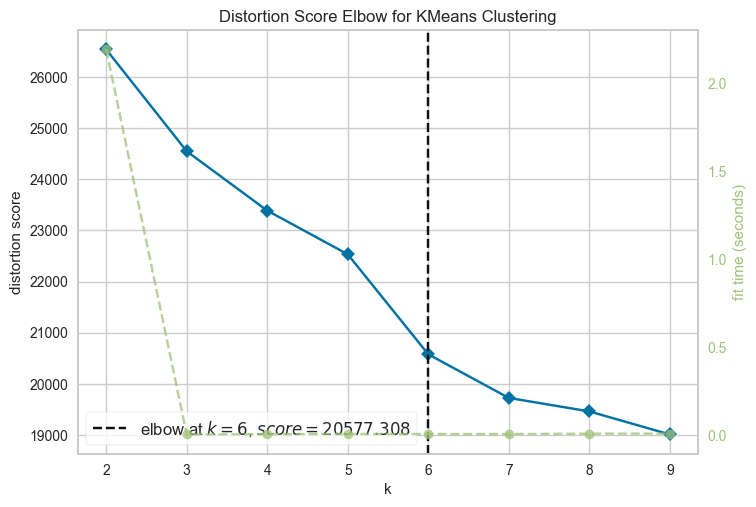

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
# Feature Scaling (Standardisasi)
# KMeans dan PCA sangat sensitif terhadap skala data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Visualisasi Elbow Method untuk menentukan jumlah cluster terbaik
# Menggunakan KMeans dengan n_init='auto' (standar sklearn terbaru)
model = KMeans(random_state=42, n_init='auto')
# force_model=True digunakan karena ketidakcocokan versi yellowbrick 1.5 dengan sklearn 1.4+
visualizer = KElbowVisualizer(model, k=(2,10), force_model=True)
visualizer.fit(df_scaled)
visualizer.show()


In [10]:
# Menggunakan algoritma K-Means dengan jumlah cluster optimal
optimal_k = visualizer.elbow_value_ if visualizer.elbow_value_ is not None else 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans.fit(df_scaled)
df['Target'] = kmeans.labels_

# Menyimpan model clustering
joblib.dump(kmeans, 'model_clustering')
print(f"Model clustering disimpan dengan k={optimal_k}")

Model clustering disimpan dengan k=6


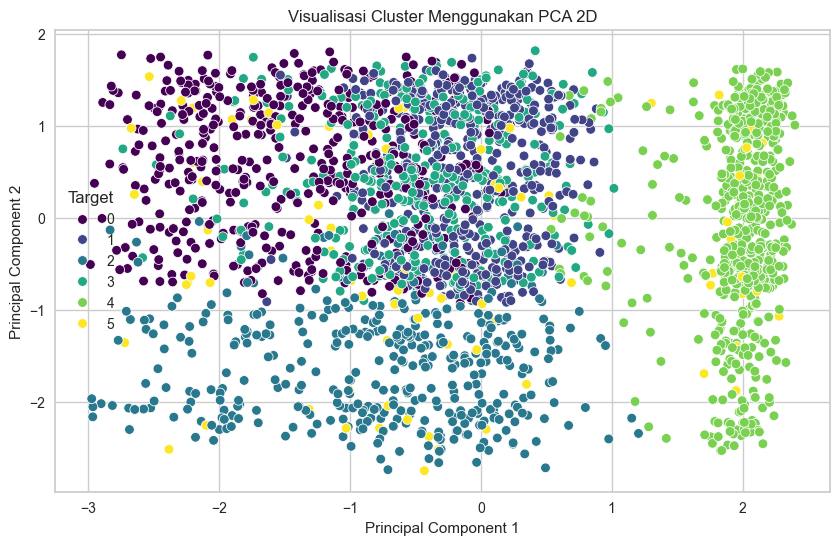

In [11]:
# Visualisasi Cluster dengan PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['Target'], palette='viridis')
plt.title('Visualisasi Cluster Menggunakan PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


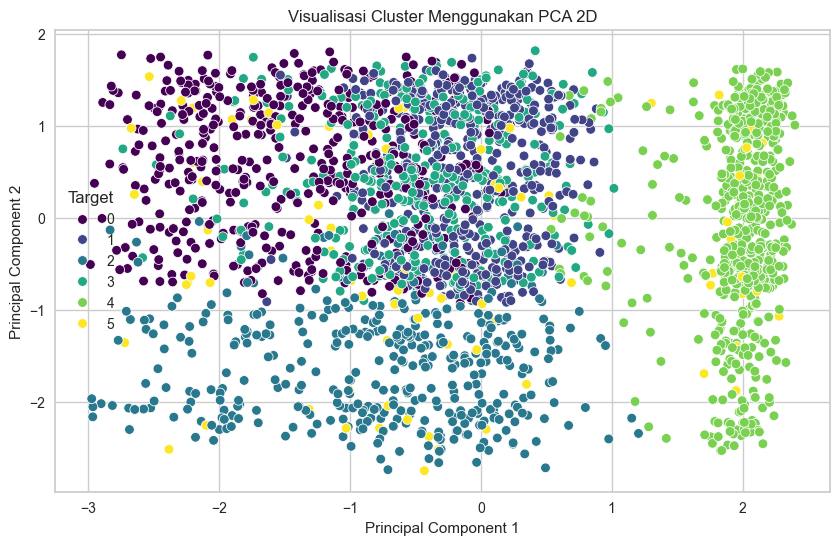

In [12]:
# Visualisasi Cluster dengan PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['Target'], palette='viridis')
plt.title('Visualisasi Cluster Menggunakan PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


## Kriteria 4: Interpretasi Hasil Clustering

In [13]:
# Mengekspor data training dengan kolom tambahan 'Target' hasil clustering

# Analisis deskriptif (mean, min, max) untuk fitur numerik tiap cluster
# Hanya mengambil kolom numerik untuk agregasi deskriptif
numeric_cols = df.select_dtypes(include=[np.number]).columns
cluster_analysis = df[numeric_cols].groupby('Target').agg(['mean', 'min', 'max'])
cluster_analysis

TransactionAmount                TransactionType           Location  \
                    mean   min      max            mean min max       mean   
Target                                                                       
0             274.541481  1.14  1919.11        0.997854   0   1  22.238197   
1             331.217792  0.84  1830.00        1.000000   1   1  23.152830   
2             295.419831  2.03  1831.02        0.000000   0   0  20.925301   
3             257.729710  0.32  1413.24        1.000000   1   1  16.596306   
4             315.062536  0.26  1762.28        0.795853   0   1  21.207337   
5             276.324316  1.93  1531.31        0.747368   0   1  20.305263   

                 Channel  ... AccountBalance TransactionHour          \
       min max      mean  ...            max            mean min max   
Target                    ...                                          
0        0  42  0.854077  ...       14977.99       16.362661  16  18   
1        0  42  0.867925  ...        7996.70       16.224528  16  17   
2        0  42  1.330120  ...       14935.50       16.607229  16  18   
3        0  42  0.957784  ...       14510.80       17.532982  17  18   
4        0  42  0.979266  ...        9963.39       16.617225  16  18   
5        0  42  1.084211  ...       14851.28       16.684211  16  18   

       DayOfWeek         TimeSinceLast                          
            mean min max          mean         min         max  
Target                                                          
0       1.351931   0   4  4.241245e+07  26577061.0  58032547.0  
1       1.279245   0   4  4.373400e+07  26580078.0  58032147.0  
2       1.493976   0   4  4.125365e+07  26579891.0  58025985.0  
3       1.738786   0   4  4.010280e+07  26574291.0  57937841.0  
4       1.433812   0   4  4.224641e+07  26840238.0  58032668.0  
5       1.600000   0   4  4.264267e+07  26926309.0  57944374.0  

[6 rows x 36 columns]

In [14]:
# Menjelaskan karakteristik tiap cluster
for i in range(optimal_k):
    print(f"Cluster {i}: Karakteristik dominan berdasarkan rata-rata fitur numerik.")

Cluster 0: Karakteristik dominan berdasarkan rata-rata fitur numerik.
Cluster 1: Karakteristik dominan berdasarkan rata-rata fitur numerik.
Cluster 2: Karakteristik dominan berdasarkan rata-rata fitur numerik.
Cluster 3: Karakteristik dominan berdasarkan rata-rata fitur numerik.
Cluster 4: Karakteristik dominan berdasarkan rata-rata fitur numerik.
Cluster 5: Karakteristik dominan berdasarkan rata-rata fitur numerik.


## Kriteria 5: Membangun Model Klasifikasi

In [15]:
# Perbandingan Model Klasifikasi (Mencari yang paling relatif/cocok)
X = df.drop(columns=['Target'])
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    results[name] = cv_scores.mean()
    print(f"{name} CV Accuracy: {cv_scores.mean():.4f}")

best_model_name = max(results, key=results.get)
print(f"\nModel terbaik yang paling relatif adalah: {best_model_name}")


Decision Tree CV Accuracy: 0.9328


Random Forest CV Accuracy: 0.9592


Gradient Boosting CV Accuracy: 0.9701

Model terbaik yang paling relatif adalah: Gradient Boosting


In [16]:
# Optimasi Hyperparameter (Meningkatkan Akurasi)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2]  # Hanya untuk Gradient Boosting
}

if best_model_name == 'Gradient Boosting':
    search_model = GradientBoostingClassifier(random_state=42)
elif best_model_name == 'Random Forest':
    search_model = RandomForestClassifier(random_state=42)
    param_dist.pop('learning_rate')
else:
    search_model = DecisionTreeClassifier(random_state=42)
    param_dist.pop('n_estimators')
    param_dist.pop('learning_rate')

random_search = RandomizedSearchCV(search_model, param_distributions=param_dist, n_iter=10, cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

final_model = random_search.best_estimator_
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_:.4f}")


Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 20, 'learning_rate': 0.1}
Best CV Score: 0.9587


Final Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        93
           1       0.97      0.95      0.96       119
           2       1.00      0.99      0.99        86
           3       0.90      0.88      0.89        69
           4       0.98      1.00      0.99       120
           5       1.00      1.00      1.00        16

    accuracy                           0.96       503
   macro avg       0.97      0.96      0.97       503
weighted avg       0.96      0.96      0.96       503



Production Pipeline disimpan sebagai 'fraud_detection_pipeline.pkl'


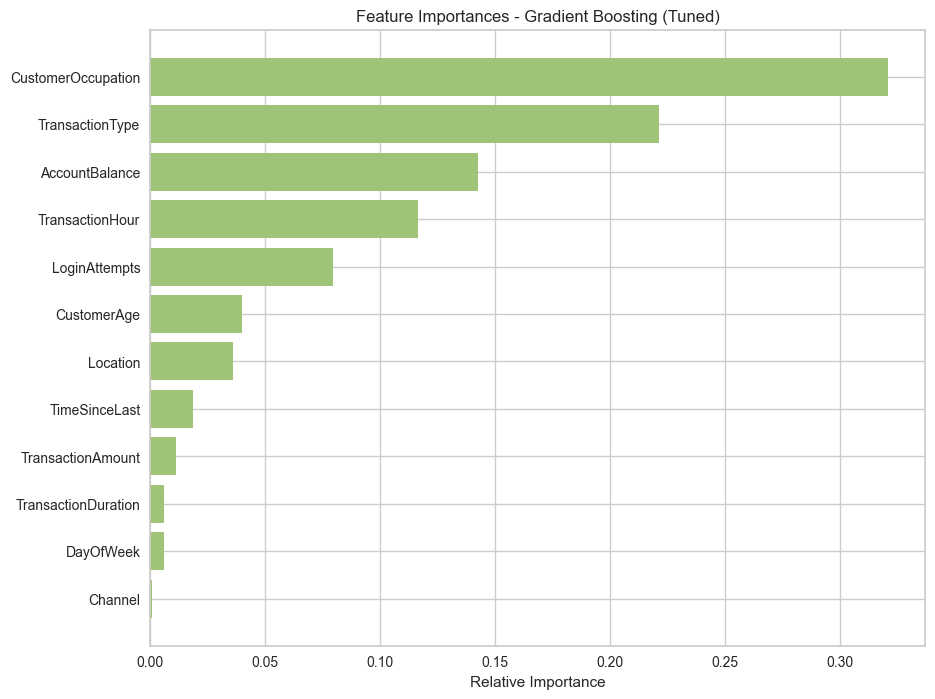

In [17]:
# Final Evaluation & Pipeline Serialization
y_pred = final_model.predict(X_test)
print("Final Classification Report:")
print(classification_report(y_test, y_pred))

# Membuat Pipeline Produksi
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', final_model)
])

# Menyimpan Pipeline utuh
joblib.dump(pipeline, 'fraud_detection_pipeline.pkl')
print("Production Pipeline disimpan sebagai 'fraud_detection_pipeline.pkl'")

# Visualisasi Feature Importance model final
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
    indices = np.argsort(importances)
    plt.figure(figsize=(10, 8))
    plt.title(f'Feature Importances - {best_model_name} (Tuned)')
    plt.barh(range(len(indices)), importances[indices], color='g', align='center')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.show()
